### Install required libraries

Using torchaudio==2.8 here as 2.9 forces the use of torchcodec:

In [51]:
%pip install pandas numpy matplotlib torch torchaudio==2.8 snntorch soundfile -q

Note: you may need to restart the kernel to use updated packages.


### Imports

In [52]:
import warnings

import numpy as np
import torch
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.config import AUDIO_CONFIG
from src.preprocessing import get_snn_pipeline, get_waveform_transformer, get_spectrogram_transformer
from src.utils import get_random_audio

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [53]:
INPUT_DIR = 'data'
MODEL_PATH = 'models/best_cnn.pth'

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 10

### Setting up device to use

In [54]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Visualising encoded data

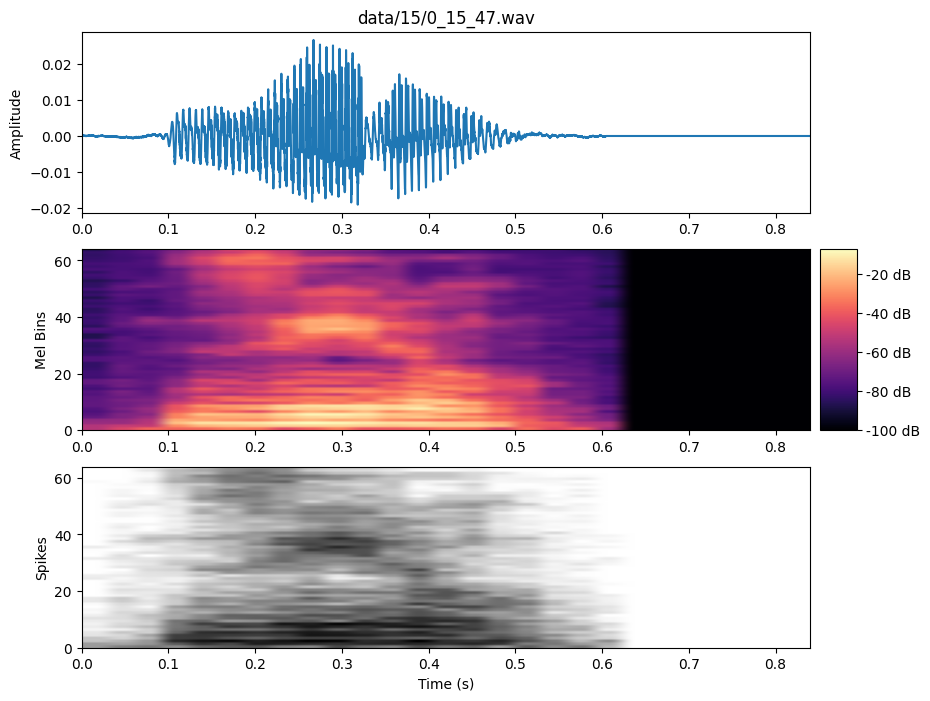

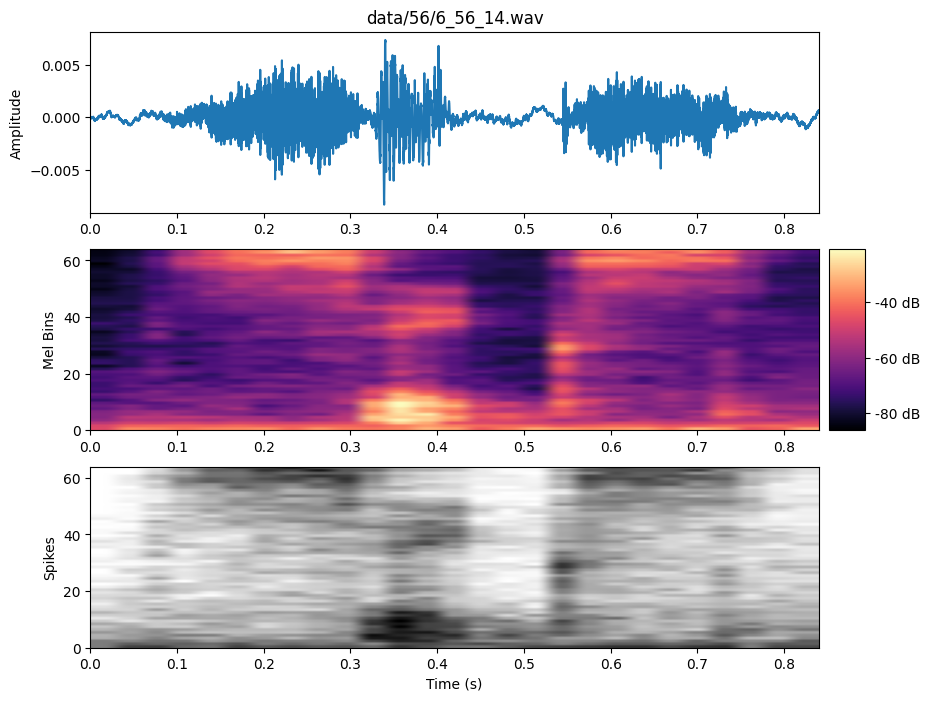

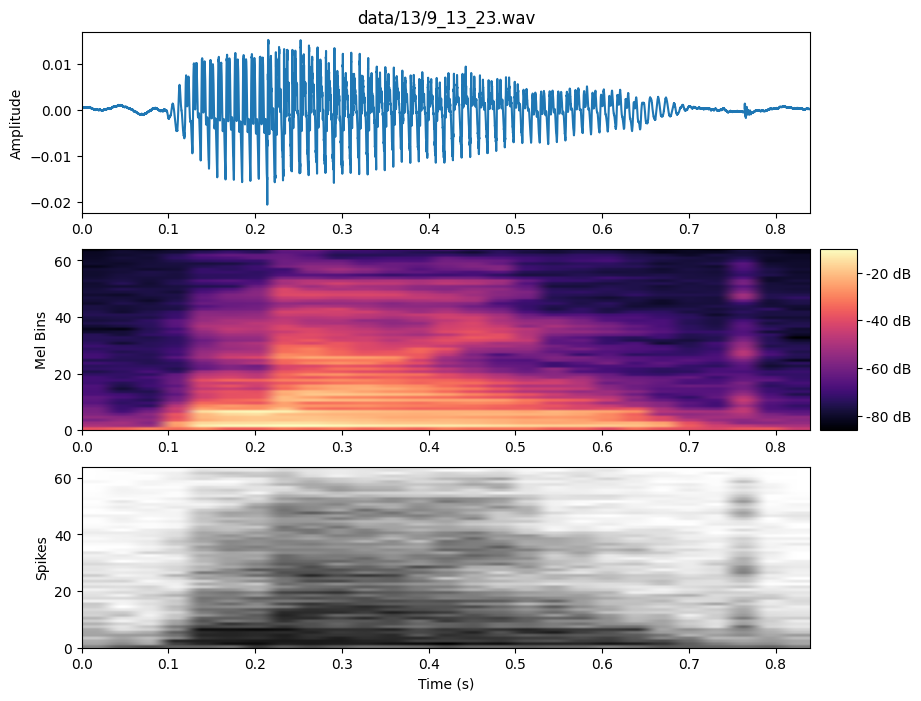

In [55]:
def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer()
    spectrogram_transformer = get_spectrogram_transformer()
    snn_pipeline = get_snn_pipeline()

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / AUDIO_CONFIG.target_sample_rate

        spikes = snn_pipeline(raw_waveform)
        spike_image = spikes.sum(dim=0).squeeze()

        # Plotting
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, AUDIO_CONFIG.n_mels],
        )
        ax2.set_ylabel('Mel Bins')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        # Spikes
        ax3.imshow(
            spike_image.numpy(),
            origin='lower',
            aspect='auto',
            cmap='binary',
            extent=[0, new_duration, 0, AUDIO_CONFIG.n_mels],
        )
        ax3.set_ylabel('Spikes')
        ax3.set_xlabel('Time (s)')

        div3 = make_axes_locatable(ax3)
        cax3 = div3.append_axes("right", size="5%", pad=0.1)
        cax3.axis("off")

        plt.show()

        display(Audio(data=new_waveform, rate=AUDIO_CONFIG.target_sample_rate))

visualise_audio_data()